# quiz 1 基礎


In [1]:
import pandas as pd

In [2]:
from other_code.quiz1 import data_segment, feature_scale, train_model, evaluate_model, save_confusion_matrix

val_ratio = 0.3

dataset = pd.read_csv("./dataset/data.csv")
X_train, X_val, y_train, y_val = data_segment(dataset,val_ratio)
X_train_scaled, X_val_scaled = feature_scale(X_train, X_val)

model = train_model(X_train_scaled, y_train)

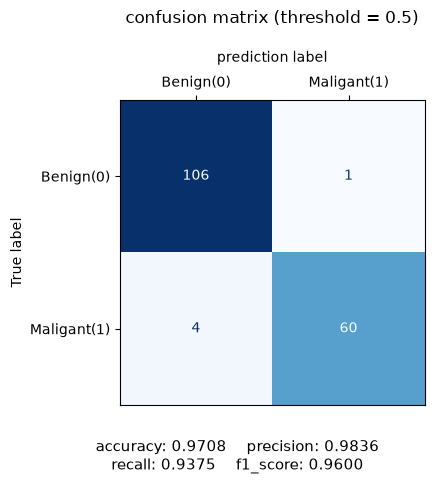

In [3]:
threshold = 0.5

cm, scores = evaluate_model(model, X_val_scaled, y_val, threshold)
save_confusion_matrix(cm, scores, save_path=f"./result/quiz1_1/confusion_matrix_{threshold}.png", threshold=threshold)

# quiz 1 進階

In [4]:
from other_code.quiz1 import train_random_forset, evaluate_model, save_confusion_matrix

rf_model = train_random_forset(X_train_scaled, y_train)

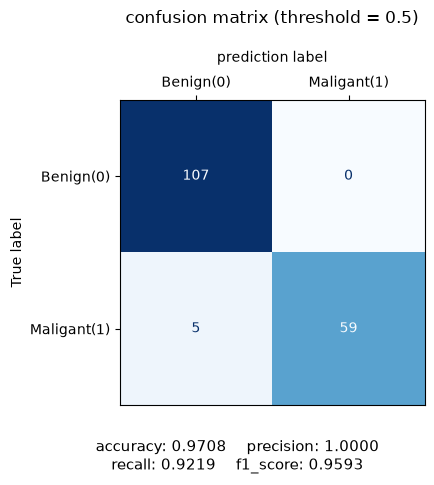

In [5]:
rf_cm, rf_scores = evaluate_model(rf_model, X_val_scaled, y_val, threshold)
save_confusion_matrix(rf_cm, rf_scores, save_path=f"./result/quiz1_2/confusion_matrix_{threshold}.png", threshold=threshold)

# quiz 2 基礎

In [6]:
import pandas as pd
import torch

In [7]:
from other_code.quiz2 import *

Batch_size = 64
Learning_rate = 0.01
Epoch = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置：{device}")

使用裝置：cuda


In [8]:
data = pd.read_csv("./dataset/UCI_Credit_Card.csv")
X_train, X_val, X_test, y_train, y_val, y_test = data_segment(data)
X_train_preprocessed, X_val_preprocessed, X_test_preprocessed, peocessor = feature_preprocess(X_train, X_val, X_test)

train_loader = create_dataloader(X_train_preprocessed, y_train, batch_size=Batch_size, shuffle=True)
val_loader = create_dataloader(X_val_preprocessed, y_val, batch_size=Batch_size, shuffle=False)
test_loader = create_dataloader(X_test_preprocessed, y_test, batch_size=Batch_size, shuffle=False)

In [9]:
input_dim = X_train_preprocessed.shape[1]
model = MLP(input_dim).to(device)

model, history = train_model(model, train_loader, val_loader, device, epochs=Epoch, learning_rate=Learning_rate, threshold=0.5)

epoch 1/50 | train loss: 0.4464, F1: 0.4472 | val loss: 0.4429, val f1: 0.4820
epoch 2/50 | train loss: 0.4338, F1: 0.4772 | val loss: 0.4420, val f1: 0.4477
epoch 3/50 | train loss: 0.4307, F1: 0.4759 | val loss: 0.4379, val f1: 0.4863
epoch 4/50 | train loss: 0.4275, F1: 0.4808 | val loss: 0.4353, val f1: 0.4545
epoch 5/50 | train loss: 0.4261, F1: 0.4774 | val loss: 0.4388, val f1: 0.4694
epoch 6/50 | train loss: 0.4252, F1: 0.4756 | val loss: 0.4345, val f1: 0.4619
epoch 7/50 | train loss: 0.4231, F1: 0.4852 | val loss: 0.4375, val f1: 0.4666
epoch 8/50 | train loss: 0.4216, F1: 0.4875 | val loss: 0.4338, val f1: 0.4586
epoch 9/50 | train loss: 0.4208, F1: 0.4819 | val loss: 0.4374, val f1: 0.4223
epoch 10/50 | train loss: 0.4184, F1: 0.4912 | val loss: 0.4413, val f1: 0.4716
epoch 11/50 | train loss: 0.4170, F1: 0.4933 | val loss: 0.4412, val f1: 0.4600
epoch 12/50 | train loss: 0.4151, F1: 0.4902 | val loss: 0.4458, val f1: 0.4770
epoch 13/50 | train loss: 0.4129, F1: 0.4938 | va

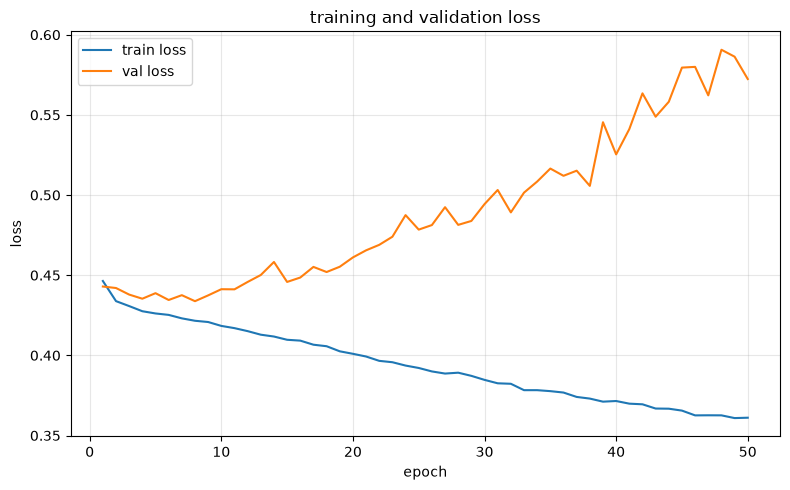

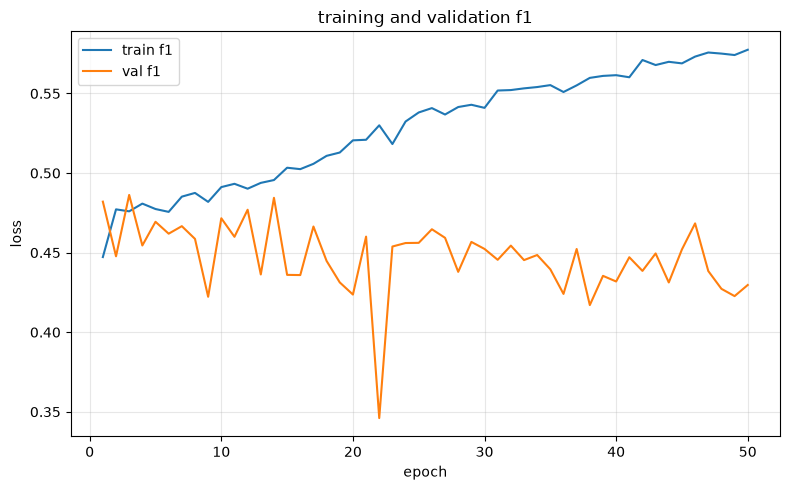

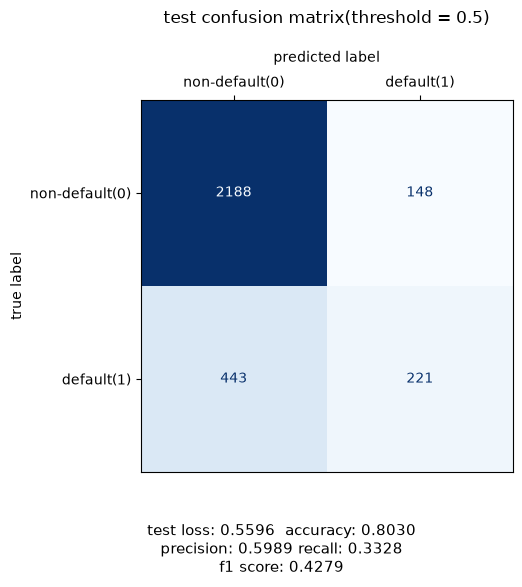

In [10]:
test_scores, test_cm = evaluate_model(model, test_loader, device, threshold=0.5)

save_result_plots(history=history, test_scores=test_scores, test_cm=test_cm, save_dir="./result/quiz2_1", prefix="quiz2_1", threshold=0.5)